## Ejercicio de Programación 5 - Reconstrucción de imagen usando Gradiente Conjugado


1. Construir matriz de transformación A
2. Implementar algoritmo de gradiente conjugado no lineal
3. Calcular función objetivo chi-cuadrado
4. Aplicar regularización si es necesario
5. Reconstruir imagen y visualizar resultados
6. Comparar con imagen verdadera y evaluar convergencia

In [80]:
%reload_ext autoreload
%autoreload 2

In [81]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

#imports
import numpy as np

# modules
from modules.simulation import visibilities_simulation
from modules.plots import plot_uv_coverage_2, plot_sources


In [82]:
VLA_L_4 = {
  "latitude": 34.078749,
  "longitude": -107.617728,
  "file_route": "../antenna_arrays/vla.a.cfg",
  "catalog_source": "LMC",
  "utc_start": "2025-10-10T00:00:00",
  "utc_end": "2025-10-10T02:00:00",
  "step_min": 5,
  "n_freqs": 4,
  "interferometer": {
    "name": "VLA",
    "band_name": "L" },
  "n_sources": 10,
  "max_offset_deg": 0.12,
  "flux_range": [5.0, 5.0],
  "seed":42
  }

V, uvw, uvw_lambda, [frequencies, channel_bandwidth], baselines_enu, sources , [l,m,n] , times_sec = visibilities_simulation(VLA_L_4)


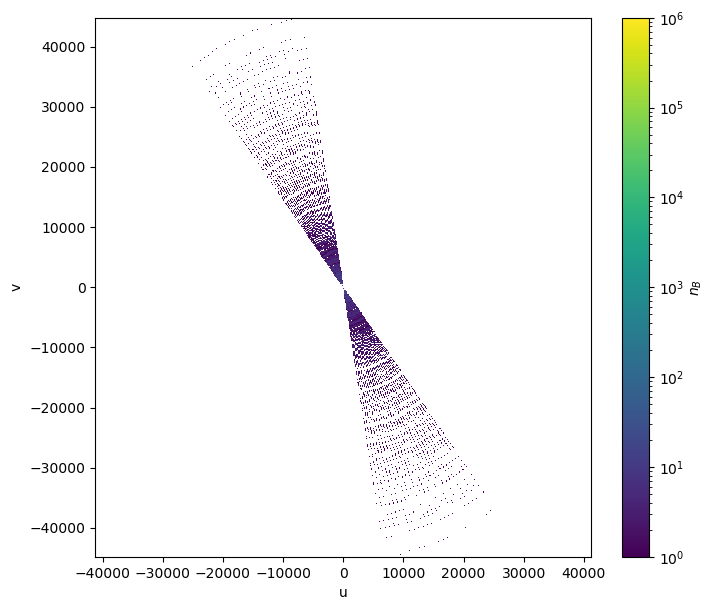

In [83]:
plot_uv_coverage_2(uvw, bins=512)

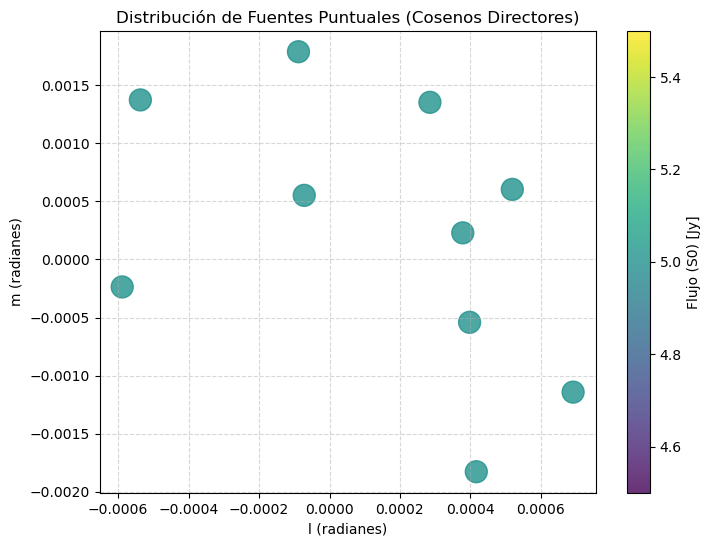

In [84]:
plot_sources(l,m,sources)

In [85]:
from modules.gridder import grid_visibilities, get_grid_config

N = 64

grid_config = get_grid_config(V, uvw_lambda, N, baselines_enu, oversampling_factor=7, frequencies=frequencies)
grid_config.keys()

dict_keys(['V', 'uvw_lambda', 'du', 'dv', 'Dmax', 'frequencies', 'oversampling_factor', 'baselines', 'Npix', 'pixel_size_image'])

In [86]:
cellsize = grid_config["pixel_size_image"]
coords = (np.arange(N) - N//2) * cellsize
l_grid, m_grid = np.meshgrid(coords, coords)

l_flat = l_grid.flatten()
m_flat = m_grid.flatten()

u = uvw_lambda[...,0]
v = uvw_lambda[...,1]

u_single = u[:,:,0].flatten()
v_single = v[:,:,0].flatten()
Vis = V[:,:,0].flatten()

Iniciando Algoritmo 1 (Identico a la guia)...
Iteración 0: Norm Residual = 6.1666e+04
Iteración 5: Norm Residual = 1.1466e+04
Iteración 10: Norm Residual = 4.7206e+03
Iteración 15: Norm Residual = 3.8257e+03
Iteración 20: Norm Residual = 6.6831e+03
Iteración 25: Norm Residual = 1.0715e+03
Iteración 30: Norm Residual = 1.6099e+04
Iteración 35: Norm Residual = 1.2577e+03
Iteración 40: Norm Residual = 9.0081e+02
Iteración 45: Norm Residual = 2.4842e+03
Iteración 50: Norm Residual = 2.9141e+03
Iteración 55: Norm Residual = 3.9658e+02
Iteración 60: Norm Residual = 1.2131e+03
Iteración 65: Norm Residual = 7.1104e+03
Iteración 70: Norm Residual = 5.1229e+03
Iteración 75: Norm Residual = 1.3488e+03
Iteración 80: Norm Residual = 6.7700e+03
Iteración 85: Norm Residual = 1.3898e+02
Iteración 90: Norm Residual = 3.5497e+02
Iteración 95: Norm Residual = 7.1946e+01
Iteración 100: Norm Residual = 4.2126e+03
Iteración 105: Norm Residual = 5.2616e+01
Iteración 110: Norm Residual = 2.1215e+02
Iteración 

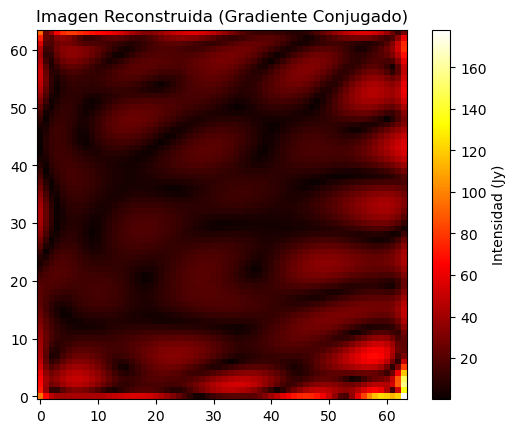

In [87]:
from modules.conj_grad import A, nonlinear_conjugate_gradient
import matplotlib.pyplot as plt

A_matrix = A(u_single, v_single, l_flat, m_flat)

imagen_reconstruida = nonlinear_conjugate_gradient(A_matrix, Vis, N, iterations=500)

# Para visualizar (tomando la magnitud o parte real)
plt.imshow(np.abs(imagen_reconstruida), origin='lower', cmap='hot')
plt.title("Imagen Reconstruida (Gradiente Conjugado)")
plt.colorbar(label='Intensidad (Jy)')
plt.show()

In [90]:
VG, WG = grid_visibilities(grid_config=grid_config, mode="numpy")

Backend a utilizar: numpy


Generating plot with scale: 6 (Figure size: 12.0x6.0 inches)


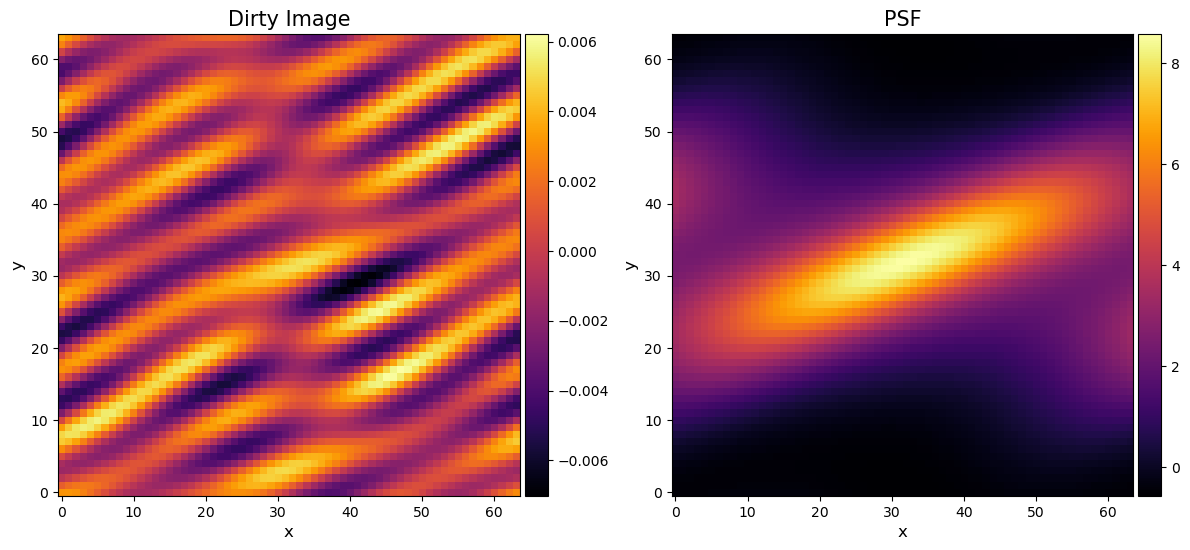

In [91]:
from modules.interferometry import get_dirty_image, get_psf, get_clean_beam
from modules.plots import plot
# import cupy as cp

dirty_image = get_dirty_image(VG)
psf = get_psf(WG)


images = [
    {'image':dirty_image, 'title':'Dirty Image', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':psf, 'title':'PSF', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
]

plot(images, (1,2), scale=6)